In [65]:
import pandas as pd
import geopandas as gpd
import shapely
import numpy as np

import re

import matplotlib.pyplot as plt
from shapely import Point, distance, Polygon
from textwrap import wrap 

import osmnx
import contextily as cx

# Preliminares


## Preguntas
Las preguntas a responder son:
1. ¿Quién crea la data, como la crea y en que contexto? 
2. ¿Que fenómenos codifica la data y en que contextos?
3. ¿Quien es el publico o el analista objetivo y cual es el uso objetivo?
4. ¿Que identificadores y atributos están presentes en la data, y cuales no lo están?
5. ¿Que relaciones existen en la data? 
	- Considera los pares identificador/valor y atributo/valor.
	- Considera las relaciones horizontales (relación entre datos que comparten un identificador) y verticales (relación entre datos que comparten un atributo).
	
6. ¿Que realidad constituyen los datos? ¿Quien se beneficia de esta y que realidades alternas eran posibles?
7. ¿Donde hay inestabilidad o fragilidad en la data y sus significados, y que revela esto?
8. ¿Como cambian los significados entre niveles: 
	- Decisiones de codificación,
	- Análisis exploratorio,
	- Interpretación de los datos,
	- Relación con otra data,
	- Los resultados "finales."

## La data

In [3]:
df_escuelas = pd.read_csv('../../POIs/educacion/centrosEducativos_noUniverstarios.csv', delimiter=';', encoding='latin')

# Preguntas

## 1. Quien creo la data, como y en que contextos?

La data esta creada por la Comunidad de Madrid, especificamente la consejería de Educación, Ciencia y Universidades. La data se actualiza de forma anual y cubre el periodo escolar de cada año. La data parece estar creada para controles juridicos internos, ya que contiene Atributos como \texttt{nif_titular} o \texttt{nif_centro}. Ademas, los metadatos\footnote{La relación entre una data a los metadatos es una relación entre la data y otra data. Responder la pregunta de quien creo la data y bajo que contextos opera a este nivel y utiliza información que existe 'fuera' de la data como texto. Sin embargo, como vemos en la data de templos de OSM, este contexto externo queda internalizado en el texto de la data misma. De todos modos el contexto forma parte del texto tanto como el mensaje o el codigo utilizado.} confirman que la creación de la data fue bajo de la Subdirección General de Régimen Jurídico. 

In [4]:
df_escuelas.columns

Index(['centro_codigo', 'centro_nombre', 'centro_tipo_codigo',
       'centro_tipo_desc_abreviada', 'centro_tipo_descripcion',
       'centro_titularidad', 'centro_titular', 'nif_titular', 'nif_centro',
       'dat_codigo', 'dat_nombre', 'direccion_via_tipo',
       'direccion_via_nombre', 'direccion_numero', 'direccion_codigo_postal',
       'municipio_codigo', 'municipio_nombre', 'distrito_codigo',
       'distrito_nombre', 'contacto_telefono1', 'contacto_telefono2',
       'contacto_telefono3', 'contacto_telefono4', 'contacto_fax',
       'contacto_web', 'contacto_email1', 'contacto_email2',
       'direccion_coor_x', 'direccion_coor_y', 'situación',
       'fecha_constitución'],
      dtype='object')

## 2. Que fenomenos codificia?

La data codifica que escuelas estan presentes dentro de la Comunidad de Madrid, siempre y cuando estas impartan algún tipo de educación no universitaria. Esto no implica que no haya universidades codificadas en la data, sino que si estan presentes imparten educación fuera del nivel universitario. Este es un ejemplo de como la data no tiene significación fija. Tomemos como ejemple el dato \texttt{(28027591, centro\_nombre): UNIVERSIDAD POLITECNICA DE MADRID}. Dado que sabemos que los metadatos asociados con esta data contienen el dato \texttt{(Data, description: Datos de los centros educativos de la Comunidad de Madrid en los que se imparten enseñanzas no universitarias:  Datos identificativos,  de localización, etapas educativas)}, el \emph{interpretante} del signo \texttt{(28027591, centro\_nombre: UNIVERSIDAD POLITECNICA DE MADRID)} es \emph{El centro educativo con el identificador 28027591 tiene el nombre Universidad Politecnica de Madrid e imparte enseñanzas no univesitarias y esta en la Comunidad de Madrid}. Por otro lado, si nos encontraramos con ese mismo dato pero sin relacionarlo a los metadatos, su \emph{interpretante} sería \emph{El centro educativo con el identificador 28027591 tiene el nombre Universidad Politecnica de Madrid}. Es decir, el \emph{interpretante} cambia en la presencia de una relación con data externa, en este caso los metadatos, aunque la realidad externa del \texttt{objeto} sea la misma.

In [5]:
df_escuelas[df_escuelas['centro_tipo_descripcion'] == 'UNIVERSIDAD']

,centro_codigo,centro_nombre,centro_tipo_codigo,centro_tipo_desc_abreviada,centro_tipo_descripcion,centro_titularidad,centro_titular,nif_titular,nif_centro,dat_codigo,...,contacto_telefono3,contacto_telefono4,contacto_fax,contacto_web,contacto_email1,contacto_email2,direccion_coor_x,direccion_coor_y,situación,fecha_constitución
2595,28027591,UNIVERSIDAD POLITECNICA DE MADRID,401,UNIVERSIDAD,UNIVERSIDAD,PÚBLICO,U. POLITECNICA DE MADRID,NaN,NaN,5,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,ALTA,1993-01-01
2596,28027606,UNIVERSIDAD AUTONOMA DE MADRID,401,UNIVERSIDAD,UNIVERSIDAD,PÚBLICO,U. AUTONOMA DE MADRID,NaN,NaN,5,...,NaN,NaN,913974123,NaN,NaN,NaN,NaN,NaN,ALTA,1993-01-01
2597,28027618,UNIVERSIDAD COMPLUTENSE DE MADRID,401,UNIVERSIDAD,UNIVERSIDAD,PÚBLICO,U. COMPLUTENSE DE MADRID,NaN,NaN,5,...,NaN,NaN,0,NaN,NaN,NaN,438543.0,4476533.0,ALTA,1993-01-01
2614,28027850,UNIV. PONTIFICIA COMILLAS DE MADRID,401,UNIVERSIDAD,UNIVERSIDAD,PRIVADO,U. PONTIFICIA COMILLAS MADRID,NaN,NaN,5,...,NaN,NaN,915596569,NaN,NaN,NaN,NaN,NaN,BAJA,1993-01-01
2617,28027886,UNIV. NACIONAL DE EDUCACION A DISTANCIA,401,UNIVERSIDAD,UNIVERSIDAD,PÚBLICO,U.N.E.D.,NaN,NaN,5,...,NaN,NaN,0,NaN,NaN,NaN,440292.0,4476619.0,BAJA,1972-08-18
2618,28027898,UNIVERSIDAD DE ALCALA DE HENARES,401,UNIVERSIDAD,UNIVERSIDAD,PÚBLICO,U. DE ALCALA DE HENARES,NaN,NaN,3,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,ALTA,1993-01-01
3957,28041810,UNIVERSIDAD CARLOS III,401,UNIVERSIDAD,UNIVERSIDAD,PÚBLICO,U. CARLOS III,NaN,NaN,2,...,NaN,NaN,916249758,NaN,NaN,NaN,NaN,NaN,ALTA,1989-05-05
4213,28044461,UNIV.'SAN PABLO' (CEU),401,UNIVERSIDAD,UNIVERSIDAD,PRIVADO,FUNDACION UNIVERSITARIA SAN PABLO (CEU),NaN,NaN,5,...,NaN,NaN,0,NaN,NaN,NaN,439074.0,4477094.0,BAJA,1993-04-19
4214,28044471,UNIV. 'ALFONSO X EL SABIO',401,UNIVERSIDAD,UNIVERSIDAD,PRIVADO,"UNIVERSIDAD PRIVADA DE MADRID, S.A.",NaN,NaN,4,...,NaN,NaN,918109101,NaN,NaN,NaN,416593.0,4478347.0,BAJA,1993-04-19
4345,28045876,UNIVERSIDAD PRIVADA ANTONIO DE NEBRIJA,401,UNIVERSIDAD,UNIVERSIDAD,PRIVADO,"UNIVERSITAS NEBRISSENSIS, S.A.",NaN,NaN,4,...,NaN,NaN,918594521,NaN,NaN,NaN,NaN,NaN,BAJA,1995-07-17


## 3. Quien es el público?

El público objetivo de esta data no esta claro. Por un lado, contiene datos que resultarían util para un oficial juridico. Aunque que la presencia de los datos en un portal abierto implica un público abierto, esto no implica que un oficial juridico no sea el público objetivo.

## 4. Que identificadores y atributos estan presentes y cuales no?

Cada centro educativo esta representado por un Identificador numerico y contiene 7689 Identificadores unicos. Los Atributos en esta data pueden ser clasificados como Atributos de clase, juridicos, the ubicación y de contacto\footnote{Los Valores relacionados con los Atributos de contact contienen numeros de telefono, de fax, direcciones web y direcciones de email. Su contenido es claro y la significación que obtienen de relaciones horizontales y verticales es obvia, por lo tanto no lo discutiremos en detalle.}. Entre los Atributos de clase estan \texttt{centro\_tipo\_descripcion}, \texttt{centro\_tipo\_desc\_abreviada} y \texttt{centro\_tipo\_codigo}. Los Valores para estos tres Atributos son diferentes signos para un mismo \emph{objeto}: el tipo de enseñanzas que imparte el centro. Aunque los tres Atributos codifican la misma realidad externa, solo los terminos usados como Valores relacionados con el Atributo \texttt{centro\_tipo\_descripcion} tienen legibilidad sin relacionarce a otros datos en la data, ya que para saber cual es el objeto de los terminos usados como Valores relacionados con \texttt{centro\_tipo\_desc\_abreviada} y \texttt{centro\_tipo\_codigo} hay que saber cual es la descripción asociada con cada codigo y abreviación. Sin embargo, incluso sin saber cual es el objeto de estos Valores estos tienen significación derivada de su diferencía; esto es, la significación que emerge del hecho de que el par \texttt{centro\_tipo\_codigo / 8} no es el par \texttt{centro\_tipo\_codigo / 14}, o que el par \texttt{centro\_tipo\_desc\_abreviada / EIPR} no es el par \texttt{centro\_tipo\_desc\_abreviada / CP INF-PRI}. De hecho, el trio de columnas generadas por estos Atributos tienen, al nivel de significación que emergen de la relación entre datos, la misma significación\footnote{}. En efecto, podriamos escoger una de las tres y descartar las otras dos de manera arbitraria y no perder ninguna significación. El hecho de que los datos en dos de estas columnas no le dirian a la analista nada sobre el \emph{objeto} que codifican, pero todavia tendrian un \emph{interpretante} en un análisis de los datos se debe al segundo principio mencionado en el prólogo de la habilidad de la data de construir una realidad interna y permitirle a la analista trabajar sin referencía a una realidad externa. 

En cuanto a los terminos de los Valores relacionados con el Atributo \texttt{centro\_tipo\_descripcion}, estos varian en su especificidad. Incluyen terminos como 'COLEGIO DE EDUCACIÓN INFANTIL Y PRIMARIA', 'CENTRO PRIVADO DE EDUCACIÓN DE PERSONAS ADULTAS' o 'CENTRO AUTORIZADO DE ENSEÑANZAS DEPORTIVAS GRADO MEDIO Y SUPERIOR' que indican que grupo de edad o nivel educativo atiende el centro respectivo. También hay terminos que dicen en que ambito o campo de conocimiento esta la educación que se imparte, como por ejemplo los terminos 'CONSERVATORIO PROFESIONAL DE MÚSICA' o 'ESCUELA DE ARTE'. 

In [6]:
df_escuelas.columns.tolist()

['centro_codigo',
 'centro_nombre',
 'centro_tipo_codigo',
 'centro_tipo_desc_abreviada',
 'centro_tipo_descripcion',
 'centro_titularidad',
 'centro_titular',
 'nif_titular',
 'nif_centro',
 'dat_codigo',
 'dat_nombre',
 'direccion_via_tipo',
 'direccion_via_nombre',
 'direccion_numero',
 'direccion_codigo_postal',
 'municipio_codigo',
 'municipio_nombre',
 'distrito_codigo',
 'distrito_nombre',
 'contacto_telefono1',
 'contacto_telefono2',
 'contacto_telefono3',
 'contacto_telefono4',
 'contacto_fax',
 'contacto_web',
 'contacto_email1',
 'contacto_email2',
 'direccion_coor_x',
 'direccion_coor_y',
 'situación',
 'fecha_constitución']

In [7]:
df_escuelas['centro_codigo'].drop_duplicates().shape

(7689,)

In [8]:
tiposCount = pd.Series(df_escuelas['centro_tipo_descripcion'].value_counts())
tiposFreq = pd.Series(df_escuelas['centro_tipo_descripcion'].value_counts(normalize=True))
tiposCount[tiposCount > 50]

centro_tipo_descripcion
ESCUELA INFANTIL PRIVADA                                             1211
COLEGIO DE EDUCACIÓN INFANTIL Y PRIMARIA                              919
CENTRO PRIVADO DE EDUCACIÓN INFANTIL Y PRIMARIA                       541
CENTRO PRIVADO DE EDUCACIÓN INFANTIL, PRIMARIA Y SECUNDARIA           503
ESCUELA INFANTIL                                                      432
INSTITUTO DE EDUCACIÓN SECUNDARIA                                     396
CENTRO PRIVADO DE EDUCACION PREESCOLAR                                384
CENTRO PRIVADO DE FORMACIÓN PROFESIONAL ESPECÍFICA                    330
CENTRO PUBLICO DE EDUCACION GENERAL BASICA                            290
CENTRO PRIVADO DE EDUCACIÓN GENERAL BASICA                            288
CENTRO PRIVADO DE EDUCACIÓN INFANTIL                                  226
ESCUELA  INFANTIL-CASA DE NIÑOS                                       213
CENTRO DOCENTE EXTRANJERO EN ESPAÑA                                   131
CENTRO PRIVADO

In [45]:
tiposFreq.shape

(115,)

## 5. Que relaciones existen?

\begin{table}[ht!]
\centering
\begin{tabularx}{\textwidth}{|r|X|X|}
\hline
\textbf{Código} & \textbf{Centro\_tipo\_descripción} & \textbf{Centro\_titularidad} \\
\hline\hline
60  & ESCUELA INFANTIL PRIVADA & PRIVADO CONCERTADO \\
\hline
152 & ESCUELA INFANTIL PRIVADA & PRIVADO \\
\hline
\end{tabularx}
\caption{Ejemplo de centros educativos con descripciones y titularidades codificadas.}
\label{tab:centrosEduEjemplo}
\end{table}

Si tomamos los datos en la columna \texttt{centro\_tipo\_descripcion} y para cada uno observamos el correspondiente dato relacionado horizontalmente en la columna \texttt{centro\_titularidad} observamos lo que a primera vista aparece ser una contradicción entre los datos, pero que bajo una inspección mas cuidadosa mostrara una forma diferente a las que hemos visto de como relaciones horizontales entre datos pueden dar significación. Consideremos las filas en la tabla \ref{tab:centrosEduEjemplo}. Ambos datos en la primera columna tienen el Valor 'ESCUELA INFANTIL PRIVADA', pero uno esta relacionado horizontalmente con un dato con el Valor 'PRIVADO CONCERTADO' y el otro con un dato con el Valor 'PRIVADO'. Ya que el termino 'PRIVADA' indica que la escuela no le pertenece al estado y el Valor que se relacione con el Atributo \texttt{centro\_titularidad} indica a quien le pertenece la escuela, este par de datos establece el termino 'PRIVADA' como un termino incierto; en un dato el termino 'PRIVADA' significa que la escuela es administrada y poseida enteramente de manera privada, mientras que en el otro, este mismo termino significa que la escuela esta bajo el tutelaje de ambos el estado y dueños privados. Sin embargo, si tratamos el par de datos relacionados horizontalmente como la unidad significante, es decir, como un solo signo, por ejemplo para obtener el signo \texttt{(60, centro\_tipo\_descripcion) : ESCUELA_INFANTIL_PRIVADA + (60, centro\_titularidad) : PRIVADO CONCERTADO}, conseguimos signos con significaciones mas especificos y claros; en concreto el primer par entonces tendria como \emph{interpretante} \emph{Escuela Infantil de propiedad privada pero financiada por el estado} mientras que el segundo par tendria como \emph{interpretante} \emph{Escuela infantil con dueño y finanziación privada}. Hecho esto, podemos eliminar el termino incierto y ahora redundante para obtener datos como las de la tabla \ref{tab:centrosEduEjemplo2}. En resumido, los Valores relacionados con el Atributo \texttt{centro\_tipo\_descripcion} tienen relación ambigua cuando tomados por si solos, pero consiguen una significación mas fija cuando se les trata como parte un signo compuesto por el dato de la misma fila en la columna \texttt{centro\_titularidad}. El hecho de que los \emph{interpretantes} de los datos en la columna \texttt{centro\_tipo\_descripcion} cambia al relacionarse horizontalmente con un dato en la columna \texttt{centro\_titularidad} pero su inteligibilidad no cambia demuestra que la significación de la data emerge de las relaciones y ademas no es fija.

\begin{table}[ht!]
\centering
\begin{tabularx}{\textwidth}{|r|X|X|}
\hline
\textbf{Código} & \textbf{Centro\_tipo\_descripción} & \textbf{Centro\_titularidad} \\
\hline\hline
60  & ESCUELA INFANTIL & PRIVADO CONCERTADO \\
\hline
152 & ESCUELA INFANTIL & PRIVADO \\
\hline
\end{tabularx}
\caption{La tabla \ref{tab:centrosEduEjemplo} luego de la modificación de sus terminos.}
\label{tab:centrosEduEjemplo2}
\end{table}


In [10]:
map_educationLevel = {
    "COLEGIO DE EDUCACIÓN INFANTIL Y PRIMARIA" : "INFANTIL_PRIMARIA",
    "ESCUELA INFANTIL PRIVADA" : "INFANTIL",
    "CENTRO PRIVADO DE EDUCACIÓN INFANTIL, PRIMARIA Y SECUNDARIA" :  "INFANTIL_PRIMARIA_SECUNDARIA",
    "ESCUELA INFANTIL" : "INFANTIL",
    "INSTITUTO DE EDUCACIÓN SECUNDARIA" : "SECUNDARIA",
    "CENTRO PRIVADO DE FORMACIÓN PROFESIONAL ESPECÍFICA" : "FORMACIONPROFESIONAL",
    "ESCUELA  INFANTIL-CASA DE NIÑOS" : "INFANTIL",
    "CENTRO DOCENTE EXTRANJERO EN ESPAÑA" : "OTRO",
    "ESCUELA MUNICIPAL DE MÚSICA" : "MUSICA",
    "CENTRO PÚBLICO DE EDUCACIÓN DE PERSONAS ADULTAS" : "EDUCACIONADULTA",
    "CENTRO PRIVADO DE EDUCACIÓN INFANTIL" : "INFANTIL",
    "CENTRO AUTORIZADO DE ENSEÑANZAS DEPORTIVAS GRADO MEDIO Y SUPERIOR" : "SECUNDARIA_SUPERIOR",
    "CENTRO PRIVADO DE EDUCACIÓN INFANTIL Y PRIMARIA" : "INFANTIL_PRIMARIA",
    "CENTRO PRIVADO DE EDUCACIÓN ESPECIAL" : "EDUCACIONESPECIAL",
    "COLEGIO DE EDUCACIÓN INFANTIL, PRIMARIA Y SECUNDARIA" : "INFANTIL_PRIMARIA_SECUNDARIA",
    "EQUIPO DE ORIENTACIÓN EDUCATIVA Y PSICOPEDAGÓGICA. GENERAL." : "OTRONOEDUCATIVO",
    "ZONA CASAS DE NIÑOS" : "INFANTIL",
    "CENTRO PRIVADO DE EDUCACIÓN SECUNDARIA" : "SECUNDARIA",
    "ESCUELA MUNICIPAL DE MÚSICA Y DANZA" : "MUSICA_DANZA",
    "ESCUELA OFICIAL DE IDIOMAS" : "IDIOMAS",
    "COLEGIO DE EDUCACIÓN ESPECIAL" : "EDUCACIONESPECIAL",
    "CENTRO PRIVADO DE EDUCACIÓN PRIMARIA Y SECUNDARIA" : "PRIMARIA_SECUNDARIA",
    "EQUIPO DE ORIENTACIÓN EDUCATIVA Y PSICOPEDAGÓGICA. ATENCIÓN TEMPRANA" : "OTRONOEDUCATIVO",
    "CENTRO AUTORIZADO ELEMENTAL DE MÚSICA" : "MUSICA",
    "CONSERVATORIO PROFESIONAL DE MÚSICA" : "MUSICA",
    "CENTRO AUTORIZADO PROFESIONAL DE MÚSICA" : "MUSICA",
    "AULA HOSPITALARIA" : "HOSPITALARIA",
    "CENTRO PRIVADO DE EDUCACIÓN DE PERSONAS ADULTAS" : "EDUCACIONADULTA",
    "UNIDAD DE FORMACIÓN E INSERCIÓN LABORAL" : "FORMACIONPROFESIONAL",
    "CENTRO AUTORIZADO DE ENSEÑANZAS DEPORTIVAS GRADO MEDIO" : "SECUNDARIA",
    "CENTRO EDUCATIVO-TERAPÉUTICO" : "OTRO",
    "CENTRO AUTORIZADO SUPERIOR DE MÚSICA" : "MUSICA",
    "CENTRO PÚBLICO DE EDUCACIÓN ADULTOS ESTABLECIMIENTOS PENITENCIARIOS" : "EDUCACIONADULTA_PENITENCIARIO",
    "ESCUELA MUNICIPAL DE EDUCACIÓN DE PERSONAS ADULTAS" : "EDUCACIONADULTA",
    "ESTABLECIMIENTO ADMINISTRATIVO" : "OTRONOEDUCATIVO",
    "EXTENSION ESCUELA OFICIAL DE IDIOMAS" : "IDIOMAS",
    "EQUIPO DE ORIENTACIÓN EDUCATIVA Y PSICOPEDAGÓGICA. ESPECÍFICO" : "OTRONOEDUCATIVO",
    "CENTRO PÚBLICO INTEGRADO DE FORMACIÓN PROFESIONAL" : "FORMACIONPROFESIONAL",
    "ESCUELA DE ARTE" : "ARTE",
    "CENTRO AUTORIZADO DE ARTES PLÁSTICAS Y DISEÑO" : "ARTE",
    "UNIVERSIDAD" : "UNIVERSITARIO",
    "CENTRO TERRITORIAL DE INNOVACIÓN Y FORMACIÓN" : "FORMACIONPROFESIONAL",
    "CENTRO DE FORMACIÓN PARA EL EMPLEO" : "OTRO",
    "CENTRO PRIVADO DE EDUCACIÓN PRIMARIA" : "PRIMARIA",
    "CONSERVATORIO PROFESIONAL DE DANZA" : "DANZA",
    "CENTRO AUTORIZADO ELEMENTAL DE MÚSICA Y DANZA" : "MUSICA_DANZA",
    "CENTRO DE FORMACIÓN AMBIENTAL" : "FORMACIONPROFESIONAL",
    "CENTRO AUTORIZADO SUPERIOR DE DISEÑO" : "ARTE",
    "ESCUELA SUPERIOR DE ARTE DRAMÁTICO" : "ARTE",
    "SECCIÓN DE INSTITUTO DE EDUCACIÓN SECUNDARIA" : "SECUNDARIA",
    "CENTRO AUTORIZADO PROFESIONAL DE DANZA" : "DANZA",
    "CENTRO AUTORIZADO DE ENSEÑANZAS DEPORTIVAS GRADO SUPERIOR" : "SUPERIOR",
    "CENTRO PÚBLICO DE FORMACIÓN PROFESIONAL ESPECÍFICA" : "FORMACIONPROFESIONAL",
    "CENTRO AUTORIZADO SUPERIOR DE ARTE DRAMÁTICO" : "ARTE",
    "COLEGIO DE EDUCACIÓN PRIMARIA" : "PRIMARIA",
    "CENTRO PRIVADO DE INFANTIL Y SECUNDARIA" : "INFANTIL_SECUNDARIA",
    "CONSERVATORIO SUPERIOR DE MÚSICA" : "MUSICA",
    "ESCUELA SUPERIOR DE CONSERVACIÓN Y RESTAURACIÓN BIENES CULTURALES" : "ARTE",
    "CENTRO AUTORIZADO PROFESIONAL  DE MÚSICA Y DANZA": "MUSICA_DANZA",
    "ESCUELA SUPERIOR DE CANTO" : "MUSICA",
    "ESCUELA SUPERIOR DE DISEÑO" : "ARTE",
    "CENTRO AUTORIZADO SUPERIOR DE DANZA" : "DANZA",
    "CENTRO INTEGRADO DE ENSEÑANZAS ARTÍSTICAS ELEMENTALES Y PROFESIONALES DE MÚSICA, EDUCACIÓN PRIMARIA Y SECUNDARIA" : "ARTE_PRIMARIA_SECUNDARIA",
    "CENTRO INTEGRADO DE ENSEÑANZAS ARTÍSTICAS  PROFESIONALES DE MÚSICA Y EDUCACIÓN SECUNDARIA" : "MUSICA_SECUNDARIA",
    "CONSERVATORIO SUPERIOR DE DANZA" : "DANZA",
    "CENTRO REGIONAL DE ENSEÑANZAS INTEGRADAS" : "OTRO",
    "AULA HOSPITALARIA PRIVADA" : "HOSPITALARIA",
    "CENTRO DOCENTE MILITAR": "MILITAR",
    "CENTRO AUTORIZADO ELEMENTAL Y PROFESIONAL DE MÚSICA" : "MUSICA",
    "CENTRO PÚBLICO DE ENSEÑANZAS DEPORTIVAS" : "OTRO",
    "INSTITUTO SUPERIOR MADRILEÑO DE INNOVACIÓN EDUCATIVA" : "SUPERIOR",
    "CENTRO DE FORMACIÓN PARA INTERCAMBIOS INTERNACIONALES" : "OTRO",
    "CENTRO REGIONAL DE ENRIQUECIMIENTO EDUCATIVO PARA ALUMNADO DE ALTAS CAPACIDADES INTELECTUALES" : "OTRO",
    "CENTRO DOCENTE EN EL EXTRANJERO" : "OTRO"
}

In [48]:
df_map = pd.Series(map_educationLevel)
df_map.sort_values().to_csv('escuelas_mapeoDeTipos.csv')

In [11]:
df_escuelas[df_escuelas['centro_tipo_descripcion'] == 'ESCUELA INFANTIL PRIVADA'][['centro_tipo_descripcion', 'centro_titularidad']]

,centro_tipo_descripcion,centro_titularidad
60,ESCUELA INFANTIL PRIVADA,PRIVADO CONCERTADO
152,ESCUELA INFANTIL PRIVADA,PRIVADO
415,ESCUELA INFANTIL PRIVADA,PRIVADO
667,ESCUELA INFANTIL PRIVADA,PRIVADO
807,ESCUELA INFANTIL PRIVADA,PRIVADO CONCERTADO
...,...,...
7430,ESCUELA INFANTIL PRIVADA,PRIVADO
7437,ESCUELA INFANTIL PRIVADA,PRIVADO
7438,ESCUELA INFANTIL PRIVADA,PRIVADO
7452,ESCUELA INFANTIL PRIVADA,PRIVADO


In [12]:
df_escuelas[df_escuelas['centro_titularidad'].isin(['PRIVADO', 'PRIVADO CONCERTADO'])]['centro_titular'].value_counts()

centro_titular
NO TIENE                                                    116
HIJAS DE LA CARIDAD DE SAN VICENTE DE PAUL                   15
PROUNIVERSIDAD, S.A.                                         14
NEMOMARLIN FRANCHISE, S.L.                                   12
ACADEF FÚTBOL, S.L.                                          11
                                                           ... 
FUNDACION JARDINES DE ESPAÑA                                  1
LAS NAVES, CENTRO DE FORMACION Y ATENCION SOCIOEDUCATIVA      1
ALDEAS INFANTILES SOS DE ESPAÑA                               1
ASOCIACION CANDELITA                                          1
ASOCIACION PRELABORALES NARANJOVEN                            1
Name: count, Length: 3801, dtype: int64

Si nos fijamos ahora en aquellas filas que tienen el par Atributo / Valor \texttt{centro\_titularidad / PÚBLICO} y miramos a los Valores relacionados con el Atributo \textttñ{centro\_titular} en estas filas vemos que la mayoría de escuelas pertenecen a la Comunidad de Madrid (75\%) y a un Ayuntamiento (18\%). Entre el resto de Valores notamos universiades públicas al igual que entidades del gobierno nacional como el Ministerio de Defensa, el Congreso de Diputados e incluso el Ministerio del Aire. 

In [25]:
df_escuelas[(~df_escuelas['centro_titularidad'].isin(['PRIVADO', 'PRIVADO CONCERTADO'])) & (df_escuelas['situación'] == 'ALTA') ]['centro_titular'].value_counts(normalize=True).head(50)

centro_titular
COMUNIDAD DE MADRID                                             0.760536
AYUNTAMIENTO                                                    0.201149
AYUNTAMIENTO                                                    0.016762
MINISTERIO DE DEFENSA                                           0.009579
MINISTERIO DEL INTERIOR                                         0.001437
SERVICIO MADRILEÑO DE SALUD                                     0.000958
AYUNTAMIENTO DE MADRID                                          0.000958
U. AUTONOMA DE MADRID                                           0.000479
U. POLITECNICA DE MADRID                                        0.000479
PATRONATO MUNICIPAL                                             0.000479
U. DE ALCALA DE HENARES                                         0.000479
U. COMPLUTENSE DE MADRID                                        0.000479
U. CARLOS III                                                   0.000479
MINISTERIO DE INCLUSIÓN, SEGURIDAD S

La clase de Atributos que hemos denominado 'juridicos' contiene los Atributos \emph{nif\_titular}, \emph{nif\_centro}, \emph{dat\_codigo}, \emph{dat\_nombre} y \emph{situación}. Los primeros dos Atributos tienen como Valores relacionados versiones redactadas (ej. '****0001*') del NIF del titular y del centro propio respectivamente. Los siguientes dos indican dentro de que Dirección del Area Territorial (DAT) se ubica el centro educativo. Aquí volvemos a ver redundancía en la inclusión de un codigo y un nombre que reflejan la misma información. Por ultimo, el Atrbuto \texttt{situación} solo esta relacionado con seis Valores unicos: 'ALTA', 'BAJA', 'INACTIVO', 'ANULACIÓN', 'EN TRÁMITE' y 'AUTORIZADO PENDIENTE FUNCIONAMIENTO'. Esta columna es significante\footnote{Por 'significante' queremos decir que aporta a la significación del signo al que pertenece; no es una noción de 'importancia'.}, ya que los Valores cambian el tiempo del \emph{interpretante} del Identificador con el que esta relacionado y de cualquier dato con el que se relacione horizontalmente. Es decir, la fila

\begin{table}[ht!]
\centering
\begin{tabularx}{\textwidth}{|r|X|X|}
\hline
\textbf{Código} & \textbf{Centro\_titularidad} & \textbf{situación} \\
\hline\hline
60  & PRIVADO & ALTA \\
\hline
\end{tabularx}
\end{table}

tendria como Interpretante \texttt{El centro educativo 60 es un centro privado}. Si cambiaramos el termino 'ALTA' por 'BAJA', el interpretante seria \texttt{El centro educativo 60 \emph{era} un centro privado}. Dependiendo del análisis que se este llevando a cabo, la analista podria decidir si este cambio es significante dentro del contexto del análisis, y la decisión que tome definira como es la realidad constituida por su análisis y por la data. Similarmente, sin la inclusión de este Atributo, la data dejaría ambigua su significación.

In [81]:
df_escuelas[ ['nif_titular',
 'nif_centro',
 'dat_codigo',
 'dat_nombre', 'situación']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7689 entries, 0 to 7688
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nif_titular  4974 non-null   object
 1   nif_centro   1863 non-null   object
 2   dat_codigo   7689 non-null   int64 
 3   dat_nombre   7689 non-null   object
 4   situación    7689 non-null   object
dtypes: int64(1), object(4)
memory usage: 300.5+ KB


In [ ]:
df_escuelas[df_escuelas['situación'].isin(['ALTA'])][ ['nif_titular',
 'nif_centro',
 'dat_codigo',
 'dat_nombre', 'situación']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 3918 entries, 1 to 7680
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nif_titular  3878 non-null   object
 1   nif_centro   1724 non-null   object
 2   dat_codigo   3918 non-null   int64 
 3   dat_nombre   3918 non-null   object
 4   situación    3918 non-null   object
dtypes: int64(1), object(4)
memory usage: 183.7+ KB


In [27]:
df_escuelas[['centro_titularidad', 'nif_titular']].value_counts()

centro_titularidad           nif_titular
PÚBLICO                      ****0001*      1749
                             ****7900*       105
                             ****7400*        21
PRIVADO                      ****7425*        14
                             ****3806*        14
                                            ... 
PÚBLICO-TITULARIDAD PRIVADA  ****2001*         1
                             ****1013*         1
                             ****0214*         1
                             ****0032*         1
                             ****0007*         1
Name: count, Length: 2131, dtype: int64

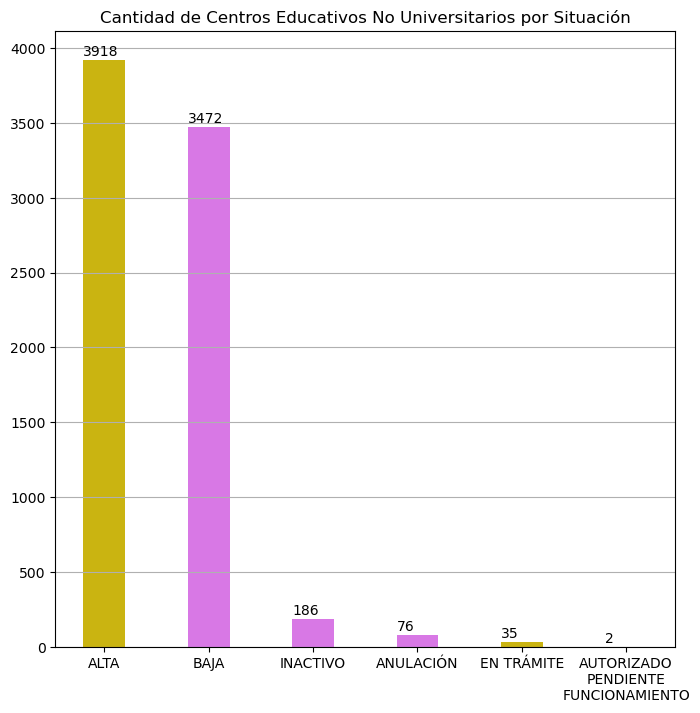

In [99]:
fig, ax = plt.subplots(figsize=(8, 8))


sitCount = df_escuelas['situación'].value_counts()
sitCount.rename({'AUTORIZADO PENDIENTE FUNCIONAMIENTO': f'AUTORIZADO\nPENDIENTE\nFUNCIONAMIENTO'}, inplace=True)

colors = ['#cab411', '#d878e5', '#d878e5', '#d878e5', '#cab411', '#d878e5']
bars = plt.bar(sitCount.index, height=sitCount.values, width=.4, color=colors)

# access the bar attributes to place the text in the appropriate location
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x(), yval + 30, yval)

labels = [ l for l in sitCount.index]
ax.set_xticks(labels)
ax.set_xticklabels(labels, rotation=0)

ax.set_title('Cantidad de Centros Educativos No Universitarios por Situación')
ax.grid(axis='y')


In [73]:
labels

['ALTA',
 'BAJA',
 'INACTIVO',
 'ANULACIÓN',
 'EN TRÁMITE',
 'AUTORIZADO PENDIENTE\nFUNCIONAMIENTO']

In [30]:
len(df_escuelas['situación'].value_counts(dropna=False).index)

6

In [44]:
df_escuelas[df_escuelas['situación'] == 'BAJA'][[col for col in df_escuelas.columns if 'contacto' in col]].dropna(how='all')

,contacto_telefono1,contacto_telefono2,contacto_telefono3,contacto_telefono4,contacto_fax,contacto_web,contacto_email1,contacto_email2
0,0,NaN,NaN,NaN,0,NaN,NaN,NaN
2,918691413,NaN,NaN,NaN,0,NaN,NaN,NaN
8,0,NaN,NaN,NaN,0,NaN,NaN,NaN
9,918896333,NaN,NaN,NaN,0,NaN,NaN,NaN
10,918880143,NaN,NaN,NaN,918880143,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
7637,916052255,NaN,NaN,NaN,916055572,http://www.educa.madrid.org/cap.parla,cap.parla@educa.madrid.org,NaN
7638,918610994,NaN,NaN,NaN,918612738,http://www.educa.madrid.org/cap.sanmartin,cap.sanmartin@educa.madrid.org,NaN
7643,915332149,915334029,NaN,NaN,915330134,http://www.educa.madrid.org/crafi.elvalle,crafi.elvalle@educa.madrid.org,NaN
7679,NaN,NaN,NaN,NaN,NaN,http://www.educa.madrid.org/cfpfp.claradelrey....,cfpfp.claradelrey.madrid@educa.madrid.org,NaN


# Despues de limpieza

In [141]:
import matplotlib.pyplot as plt
gdf_clean = gpd.read_file('../../POIs/educacion/cleaned/centrosEducativos_areaDeEstudio.shp')

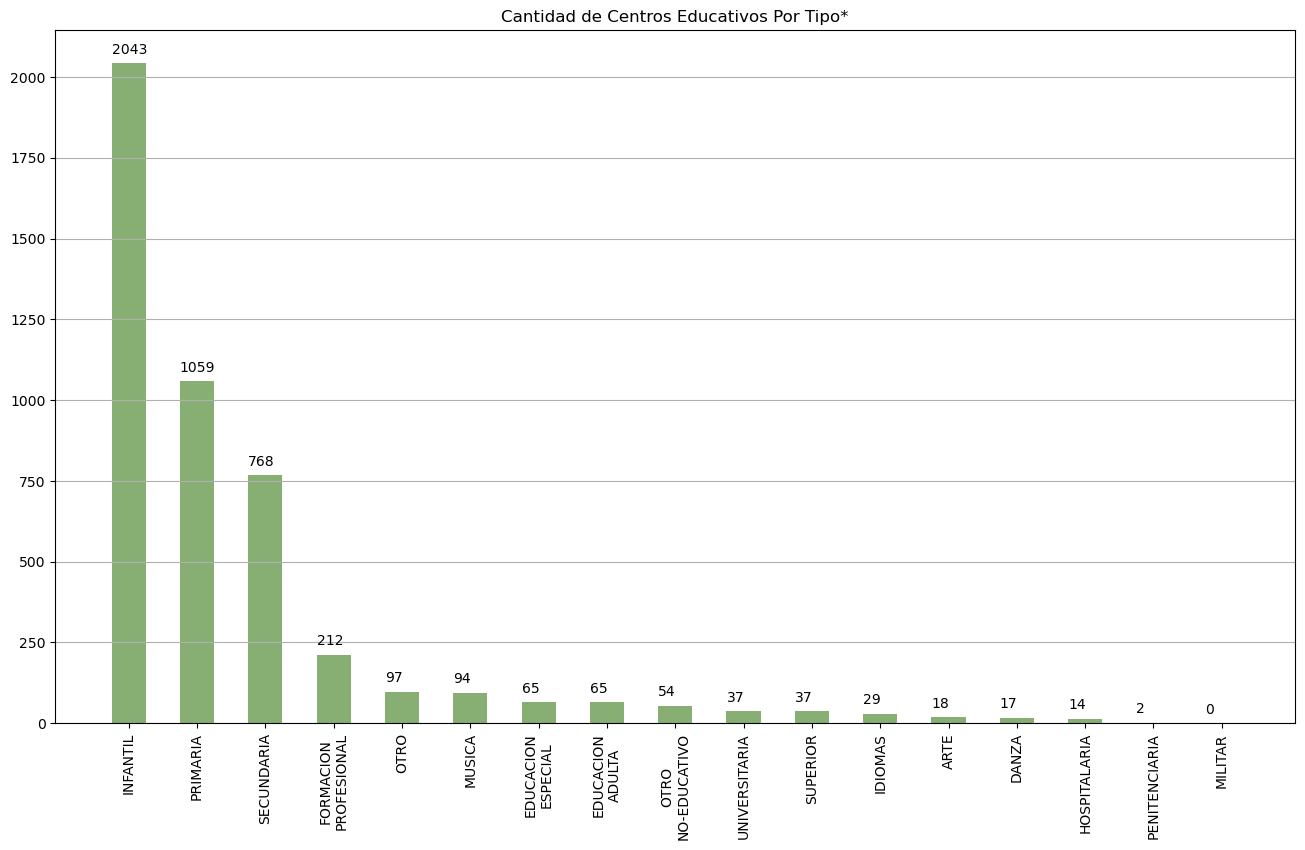

In [146]:
fig, ax = plt.subplots(figsize=(16, 9))
typeCounts = gdf_clean.iloc[:, 9:-1].rename({'FORMACIONP': 'FORMACION\nPROFESIONAL', 'EDUCACIONA' : 'EDUCACION\nADULTA', 
                                             'OTRONOEDUC' : 'OTRO\nNO-EDUCATIVO', 'EDUCACIONE' : 'EDUCACION\nESPECIAL',
                                             'UNIVERSITA' : 'UNIVERSITARIA', 'HOSPITALAR' : 'HOSPITALARIA' , 'PENITENCIA' : 'PENITENCIARIA'}, axis=1
                                            ).sum().sort_values(ascending=False)

bars = plt.bar(typeCounts.index, typeCounts.values, width=0.5, color='xkcd:sage')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x(), yval + 30, yval)

labels = typeCounts.index.tolist()
ax.set_xticks(labels)
ax.set_xticklabels(labels, rotation=90)

ax.set_title('Cantidad de Centros Educativos Por Tipo*')
ax.grid(axis='y')

In [151]:
typeCounts.iloc[3:].sum() 

np.int64(741)